# Week 3 — 

| 4 | Double Transfer Learning (two-stage fine-tuning) | DermaMNIST ↔ BloodMNIST |


In [2]:
!pip install medmnist torchvision scikit-learn matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 156.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 177.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 180.6 MB/s  0:00:00
  Attempting uninstall: sympy━━━━━━━━━━━━━━━━━━━  0/10 [tifffile]
    Found existing installation: sympy 1.14.0  0/10 [tifffile]
    Uninstalling sympy-1.14.0:━━━━━━━━━━━━━━  0/10 [tifffile]
      Successfully uninstalled sympy-1.14.0━━━━━━━━━━━━━━━━━━━━━━━  2/10 [sympy]
  Attempting uninstall: Pillow━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/10 [sympy]
    Found existing installation: Pillow 9.2.0━━━━━━━━━━━━━━━━━  2/10 [sympy]
    Uninstalling Pillow-9.2.0:m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/10 [sympy]
      Successfully uninstalled Pillow-9.2.0━━━━━━━━━━━━━━━━━━━  2/10 [sympy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [medmnist]/10 [scikit-image]


In [3]:
import os
import random
import copy
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torchvision.models import resnet50, ResNet50_Weights

import medmnist
from medmnist import DermaMNIST, BloodMNIST, INFO

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    accuracy_score, f1_score
)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Output directories ──────────────────────────────────────────────────────
os.makedirs('figures',     exist_ok=True)
os.makedirs('experiments', exist_ok=True)
os.makedirs('models',      exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

print(f"medmnist version : {medmnist.__version__}")
print(f"torch version    : {torch.__version__}")
print(f"torchvision      : {torchvision.__version__}")


Using device: cuda
GPU: Tesla T4
medmnist version : 3.0.2
torch version    : 2.5.1
torchvision      : 0.20.1


### 1.1 Global Configuration

In [4]:
# ── Shared hyperparameters ─────────────────────────────────────────────────
CONFIG = {
    # Data
    'image_size'   : 224,
    'batch_size'   : 64,
    'num_workers'  : 2,

    # Training
    'num_epochs'   : 30,
    'seed'         : 42,

    # Fine-tuning LR strategy
    'lr_full_finetune'  : 1e-4,
    'lr_linear_probe'   : 1e-3,
    'lr_backbone'       : 1e-5,
    'lr_head'           : 1e-3,

    # Regularization
    'weight_decay' : 1e-4,
    'dropout'      : 0.3,

    # Scheduler
    'scheduler'    : 'cosine',
    'step_size'    : 10,
    'gamma'        : 0.1,

    # Early stopping
    'patience'     : 7,
}

# Double-transfer specific epochs & LR
EPOCHS_STAGE1 = 15
EPOCHS_STAGE2 = 15
LR_STAGE1     = 1e-4
LR_STAGE2     = 1e-5

# SSL-specific config
SSL_CONFIG = {
    'img_size'       : 96,
    'batch_size'     : 64,
    'ssl_epochs'     : 20,
    'ssl_lr'         : 3e-4,
    'ssl_temp'       : 0.07,
    'projection_dim' : 128,
    'hidden_dim'     : 512,
    'ft_epochs'      : 15,
    'ft_lr'          : 1e-4,
    'weight_decay'   : 1e-4,
    'label_fractions': [0.1, 0.5, 1.0],
}

DATASETS = ['dermamnist', 'bloodmnist']
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("Configuration loaded.")


Configuration loaded.


### 1.2 Shared Transforms & Data Loaders

In [5]:
# ── Transforms ──────────────────────────────────────────────────────────────
train_transform_224 = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform_224 = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def get_dataloaders(dataset_name, batch_size=CONFIG['batch_size'], num_workers=2):
    """Load MedMNIST 224px dataset → (train, val, test) loaders + metadata."""
    dataset_map = {'dermamnist': DermaMNIST, 'bloodmnist': BloodMNIST}
    DatasetClass = dataset_map[dataset_name]
    info = INFO[dataset_name]
    n_classes = len(info['label'])

    train_ds = DatasetClass(split='train', transform=train_transform_224,
                            download=True, as_rgb=True)
    val_ds   = DatasetClass(split='val',   transform=val_transform_224,
                            download=True, as_rgb=True)
    test_ds  = DatasetClass(split='test',  transform=val_transform_224,
                            download=True, as_rgb=True)

    kw = dict(batch_size=batch_size, num_workers=num_workers, pin_memory=True)
    train_loader = DataLoader(train_ds, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  shuffle=False, **kw)

    print(f"[{dataset_name}] Train:{len(train_ds):>6} | Val:{len(val_ds):>5} | "
          f"Test:{len(test_ds):>5} | Classes:{n_classes}")
    return train_loader, val_loader, test_loader, n_classes, info


# Load all 224px loaders (used by Sections 2 & 4)
dataloaders = {}
for ds_name in DATASETS:
    tr, vl, te, nc, info = get_dataloaders(ds_name)
    dataloaders[ds_name] = {'train': tr, 'val': vl, 'test': te,
                             'n_classes': nc, 'info': info}


100%|██████████| 19.7M/19.7M [00:01<00:00, 13.1MB/s]


Using downloaded and verified file: /home/jovyan/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/jovyan/.medmnist/dermamnist.npz
[dermamnist] Train:  7007 | Val: 1003 | Test: 2005 | Classes:7


100%|██████████| 35.5M/35.5M [00:02<00:00, 12.8MB/s]


Using downloaded and verified file: /home/jovyan/.medmnist/bloodmnist.npz
Using downloaded and verified file: /home/jovyan/.medmnist/bloodmnist.npz
[bloodmnist] Train: 11959 | Val: 1712 | Test: 3421 | Classes:8


### 1.3 Shared Training Engine

In [6]:
def get_optimizer(model, mode, config):
    if mode == 'linear_probe':
        params = filter(lambda p: p.requires_grad, model.parameters())
        return optim.AdamW(params, lr=config['lr_linear_probe'],
                           weight_decay=config['weight_decay'])
    head_params     = list(model.fc.parameters())
    head_ids        = set(id(p) for p in head_params)
    backbone_params = [p for p in model.parameters()
                       if id(p) not in head_ids and p.requires_grad]
    return optim.AdamW([
        {'params': backbone_params, 'lr': config['lr_backbone']},
        {'params': head_params,     'lr': config['lr_head']},
    ], weight_decay=config['weight_decay'])


def get_scheduler(optimizer, config, n_epochs):
    if config['scheduler'] == 'cosine':
        return CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-7)
    return None


def train_one_epoch(model, loader, criterion, optimizer, device=DEVICE):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.squeeze().long().to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += inputs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion=None, device=DEVICE):
    model.eval()
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.squeeze().long().to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)
        total_loss += loss.item() * inputs.size(0)
        correct    += (preds == labels).sum().item()
        total      += inputs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


def train_model(model, train_loader, val_loader, config, mode,
                n_epochs=None, device=DEVICE, exp_name='exp'):
    if n_epochs is None:
        n_epochs = config['num_epochs']
    criterion = nn.CrossEntropyLoss()
    optimizer = get_optimizer(model, mode, config)
    scheduler = get_scheduler(optimizer, config, n_epochs)
    model = model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_acc, patience_counter = 0.0, 0
    best_wts = copy.deepcopy(model.state_dict())

    print(f"\n{'─'*60}\n  {exp_name} | Mode: {mode} | Epochs: {n_epochs}\n{'─'*60}")
    print(f"{'Epoch':>6} {'TrLoss':>9} {'TrAcc':>7} {'VlLoss':>9} {'VlAcc':>7} {'LR':>9}")
    print('─'*60)

    for epoch in range(1, n_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc, _, _, _ = evaluate(model, val_loader, criterion, device)
        current_lr = optimizer.param_groups[-1]['lr']
        for k, v in zip(['train_loss','train_acc','val_loss','val_acc','lr'],
                        [t_loss, t_acc, v_loss, v_acc, current_lr]):
            history[k].append(v)
        if scheduler:
            scheduler.step()
        marker = ''
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            marker = ' ★'
        else:
            patience_counter += 1
        if epoch % 5 == 0 or epoch == 1 or marker:
            print(f"{epoch:>6} {t_loss:>9.4f} {t_acc:>7.4f} {v_loss:>9.4f} {v_acc:>7.4f} "
                  f"{current_lr:>9.2e}{marker}")
        if patience_counter >= config['patience']:
            print(f"  Early stop at epoch {epoch}")
            break

    print(f"{'─'*60}\n  Best Val Acc: {best_val_acc:.4f}")
    model.load_state_dict(best_wts)
    torch.save(best_wts, f'models/{exp_name}_best.pth')
    return model, history


def compute_test_metrics(trained_model, test_loader, n_classes, info, dataset, mode):
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, preds, labels, probs = evaluate(trained_model, test_loader, criterion)
    labels_bin = label_binarize(labels, classes=list(range(n_classes)))
    try:
        auc_score = roc_auc_score(labels_bin, probs, multi_class='ovr', average='macro')
    except ValueError:
        auc_score = float('nan')
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return {
        'test_loss': test_loss, 'test_acc': test_acc, 'auc': auc_score, 'f1_macro': f1,
        'preds': preds, 'labels': labels, 'probs': probs,
        'n_classes': n_classes, 'class_names': list(info['label'].values()),
        'dataset': dataset, 'mode': mode,
    }

print("Training engine ready.")


Training engine ready.


### 1.4 Shared Plotting Utilities

In [7]:
def plot_learning_curves(histories, dataset_name, methods, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#795548']
    for i, method in enumerate(methods):
        key = f"{dataset_name}__{method}" if '__' not in method else method
        if key not in histories:
            continue
        h   = histories[key]
        eps = range(1, len(h['train_loss']) + 1)
        lbl = method.replace('_', ' ').title()
        c   = colors[i % len(colors)]
        axes[0].plot(eps, h['train_loss'], color=c, ls='-',  alpha=0.9, label=f'{lbl} – train')
        axes[0].plot(eps, h['val_loss'],   color=c, ls='--', alpha=0.9, label=f'{lbl} – val')
        axes[1].plot(eps, h['train_acc'],  color=c, ls='-',  alpha=0.9, label=f'{lbl} – train')
        axes[1].plot(eps, h['val_acc'],    color=c, ls='--', alpha=0.9, label=f'{lbl} – val')
    for ax, title, ylabel in zip(axes,
        [f'{dataset_name.upper()} — Loss', f'{dataset_name.upper()} — Accuracy'],
        ['Loss', 'Accuracy']):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


def plot_confusion_matrix(preds, labels, class_names, title, save_path=None):
    class_names = [c[:20] + '…' if len(c) > 20 else c for c in class_names]
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, data, fmt, cmap, sub in zip(
        axes, [cm, cm_norm], ['d', '.2f'], ['Blues', 'YlOrRd'],
        ['Raw counts', 'Normalized']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'{title}\n({sub})', fontsize=12, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


def plot_multiclass_roc(probs, labels, class_names, title, save_path=None):
    n_classes  = len(class_names)
    labels_bin = label_binarize(labels, classes=list(range(n_classes)))
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    for i, (name, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        short = name[:18] + '…' if len(name) > 18 else name
        ax.plot(fpr, tpr, color=color, lw=1.8, label=f'{short} (AUC={roc_auc_val:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_metric_comparison(all_results, datasets, method_order, method_labels,
                            metric='test_acc', metric_label='Test Accuracy',
                            save_path=None):
    colors = ['#90CAF9', '#FFCC80', '#A5D6A7', '#CE93D8', '#80CBC4']
    fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5))
    if len(datasets) == 1:
        axes = [axes]
    for ax, ds in zip(axes, datasets):
        values, xlabels, bar_colors = [], [], []
        for method, lbl, c in zip(method_order, method_labels, colors):
            key = f"{ds}__{method}"
            if key in all_results:
                values.append(all_results[key][metric])
                xlabels.append(lbl)
                bar_colors.append(c)
        if not values:
            continue
        bars = ax.bar(xlabels, values, color=bar_colors, edgecolor='black',
                      linewidth=0.8, width=0.55)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.set_title(f'{ds.upper()} — {metric_label}', fontsize=13, fontweight='bold')
        ax.set_ylabel(metric_label)
        ax.set_ylim([max(0, min(values)-0.05), min(1, max(values)+0.07)])
        ax.grid(axis='y', alpha=0.35)
        ax.tick_params(axis='x', labelsize=8)
    plt.suptitle(f'{metric_label} Comparison', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print("Plotting utilities ready.")


Plotting utilities ready.


In [ ]:
def build_model(n_classes, mode='full_finetune', dropout=0.3):
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    if mode == 'linear_probe':
        for param in model.parameters():
            param.requires_grad = False
    elif mode == 'partial_finetune':
        frozen_layers = ['conv1', 'bn1', 'layer1', 'layer2']
        for name, param in model.named_parameters():
            if any(name.startswith(fl) for fl in frozen_layers):
                param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_features, n_classes))
    return model


# Sanity check
for mode in ['linear_probe', 'partial_finetune', 'full_finetune']:
    m = build_model(n_classes=7, mode=mode)
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{mode:20s} | Total: {total:>10,} | Trainable: {trainable:>10,} ({100*trainable/total:.1f}%)")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 76.5MB/s]


linear_probe         | Total: 23,522,375 | Trainable:     14,343 (0.1%)
partial_finetune     | Total: 23,522,375 | Trainable: 22,077,447 (93.9%)
full_finetune        | Total: 23,522,375 | Trainable: 23,522,375 (100.0%)


### 2.1 Run All Fine-Tuning Experiments

In [ ]:
FT_EXPERIMENTS = [
    {'dataset': 'dermamnist', 'mode': 'linear_probe'},
    {'dataset': 'dermamnist', 'mode': 'full_finetune'},
    {'dataset': 'dermamnist', 'mode': 'partial_finetune'},
    {'dataset': 'bloodmnist', 'mode': 'linear_probe'},
    {'dataset': 'bloodmnist', 'mode': 'full_finetune'},
    {'dataset': 'bloodmnist', 'mode': 'partial_finetune'},
]

ft_results   = {}
ft_histories = {}
ft_models    = {}

for exp in FT_EXPERIMENTS:
    ds_name = exp['dataset']
    mode    = exp['mode']
    exp_key = f"{ds_name}__{mode}"

    set_seed()
    model = build_model(n_classes=dataloaders[ds_name]['n_classes'],
                        mode=mode, dropout=CONFIG['dropout'])

    trained_model, history = train_model(
        model, dataloaders[ds_name]['train'], dataloaders[ds_name]['val'],
        config=CONFIG, mode=mode, n_epochs=CONFIG['num_epochs'],
        device=DEVICE, exp_name=exp_key
    )

    result = compute_test_metrics(
        trained_model, dataloaders[ds_name]['test'],
        dataloaders[ds_name]['n_classes'], dataloaders[ds_name]['info'],
        ds_name, mode
    )

    ft_results[exp_key]   = result
    ft_histories[exp_key] = history
    ft_models[exp_key]    = trained_model

    print(f"[TEST] {exp_key:40s}  Acc={result['test_acc']:.4f}  "
          f"AUC={result['auc']:.4f}  F1={result['f1_macro']:.4f}")



────────────────────────────────────────────────────────────
  dermamnist__linear_probe | Mode: linear_probe | Epochs: 30
────────────────────────────────────────────────────────────
 Epoch    TrLoss   TrAcc    VlLoss   VlAcc        LR
────────────────────────────────────────────────────────────
     1    1.0306  0.6690    0.8891  0.7059  1.00e-03 ★
     2    0.8825  0.6940    0.8400  0.7168  9.97e-04 ★
     3    0.8393  0.7056    0.8137  0.7218  9.89e-04 ★
     5    0.7955  0.7071    0.7781  0.7298  9.57e-04 ★
     6    0.7886  0.7157    0.7712  0.7398  9.33e-04 ★
     7    0.7755  0.7187    0.7711  0.7438  9.05e-04 ★
     8    0.7757  0.7164    0.7536  0.7527  8.72e-04 ★
    10    0.7594  0.7241    0.7602  0.7458  7.94e-04
    15    0.7391  0.7297    0.7373  0.7507  5.52e-04
  Early stop at epoch 15
────────────────────────────────────────────────────────────
  Best Val Acc: 0.7527
[TEST] dermamnist__linear_probe                  Acc=0.7312  AUC=0.8922  F1=0.4116

──────────────────

### 2.2 Fine-Tuning: Learning Curves, Confusion Matrices & ROC

Saved: figures/S2_learning_curves_dermamnist.png


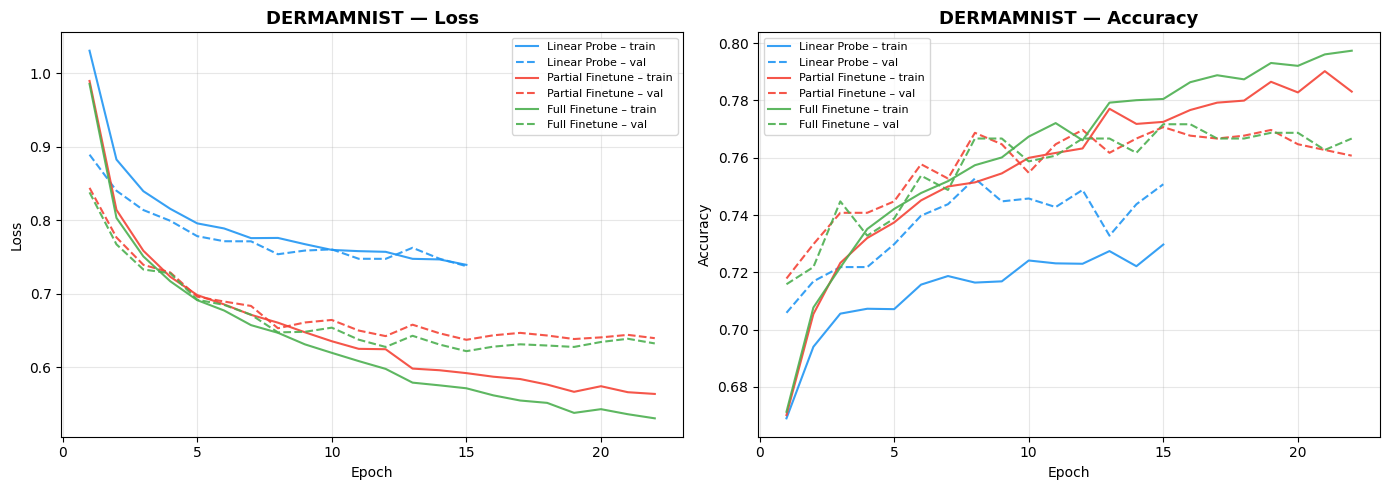

Saved: figures/S2_learning_curves_bloodmnist.png


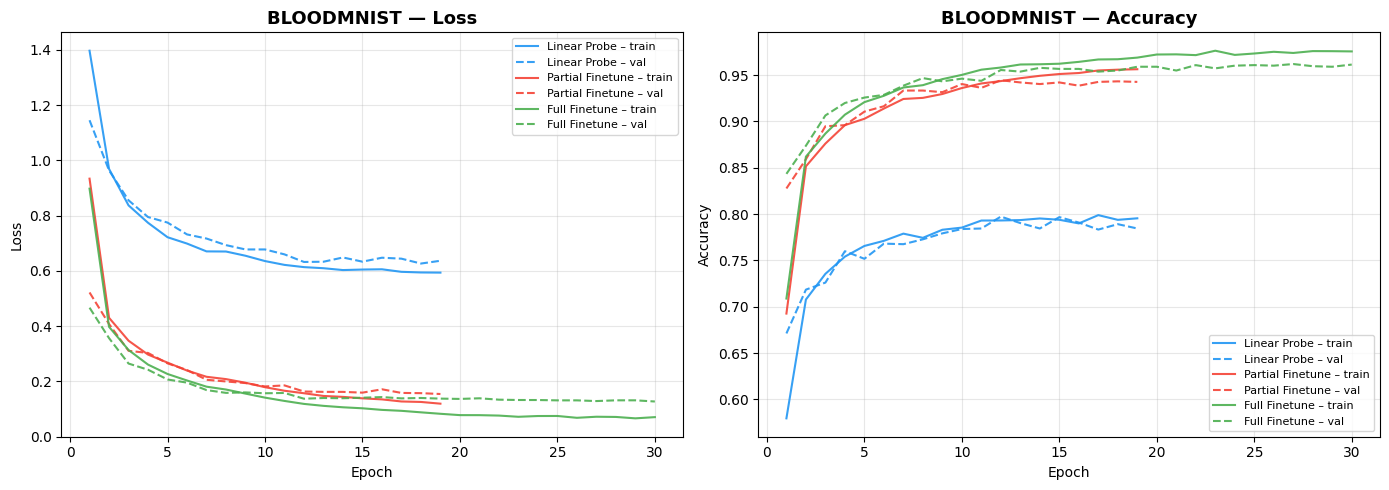

Saved: figures/S2_cm_dermamnist.png


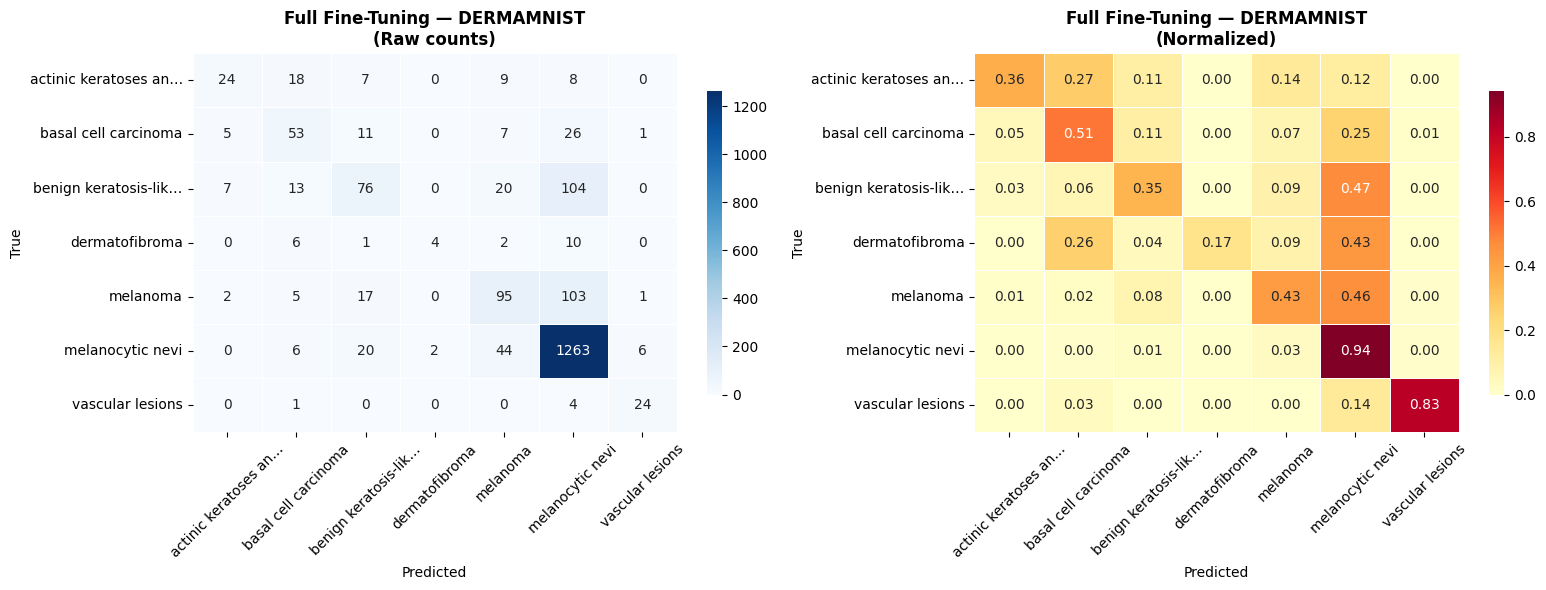

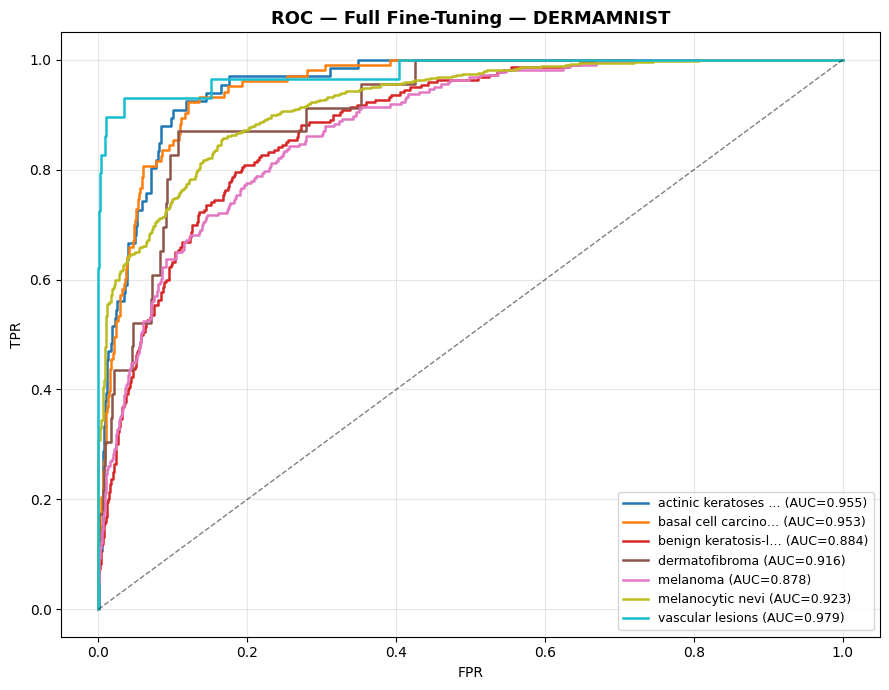

Saved: figures/S2_cm_bloodmnist.png


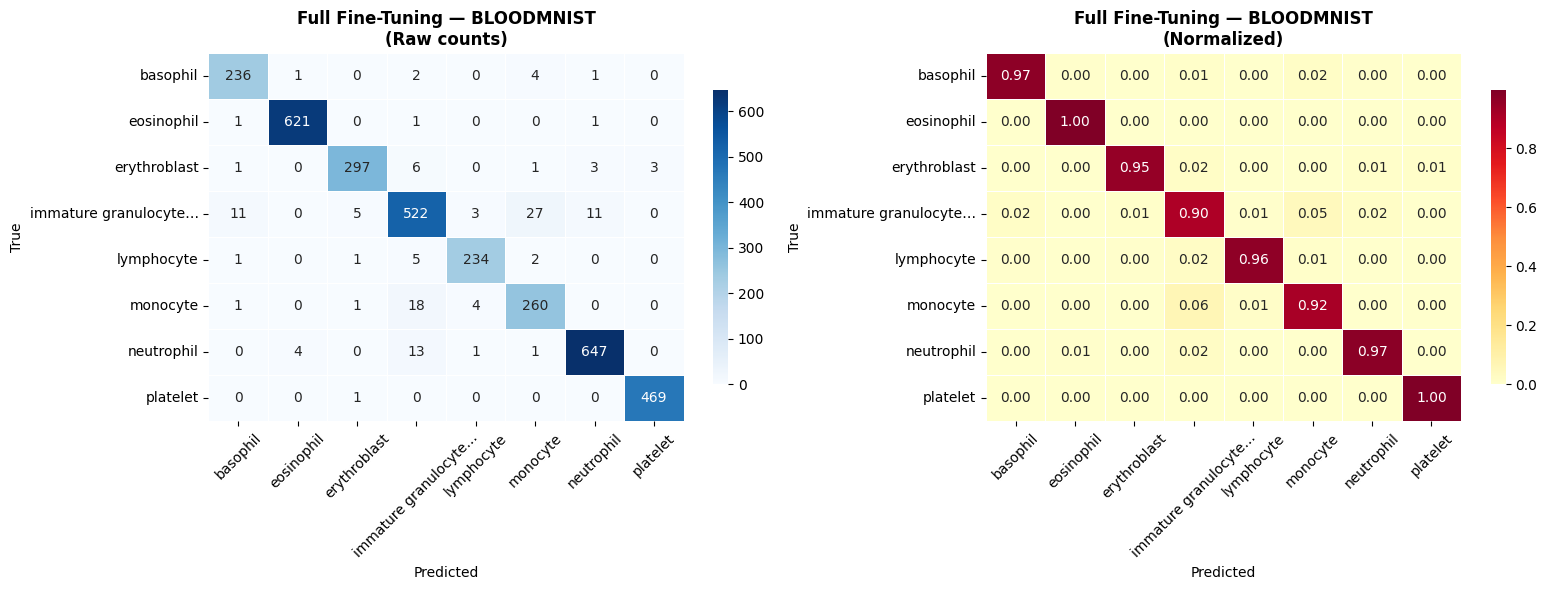

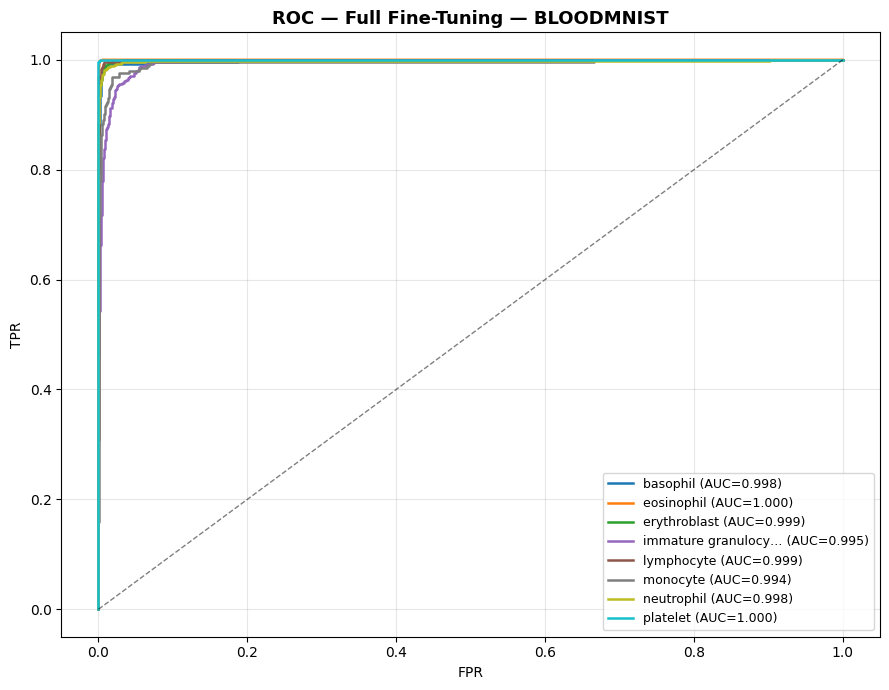

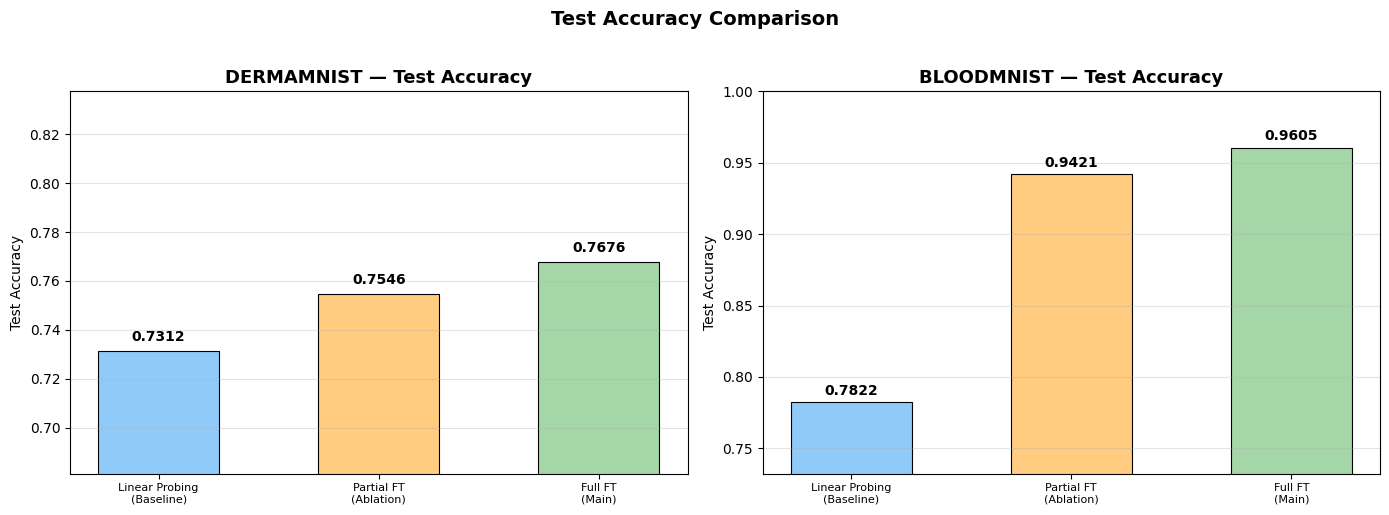

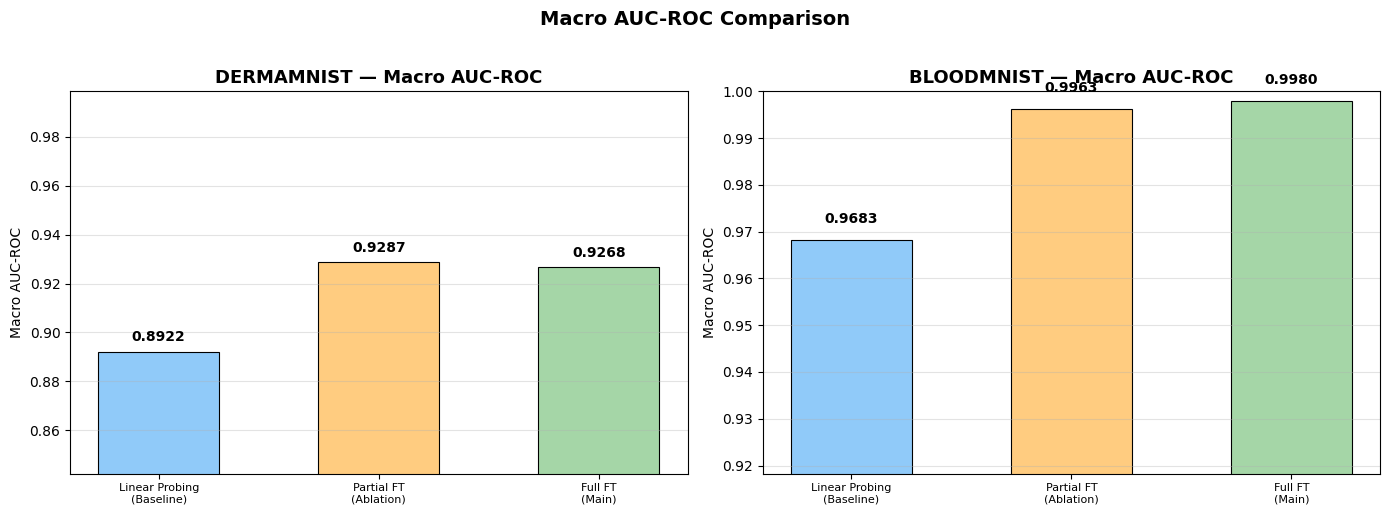

In [ ]:
FT_METHODS = ['linear_probe', 'partial_finetune', 'full_finetune']
FT_LABELS  = ['Linear Probing\n(Baseline)', 'Partial FT\n(Ablation)', 'Full FT\n(Main)']

for ds in DATASETS:
    plot_learning_curves(ft_histories, ds, FT_METHODS,
                         save_path=f'figures/S2_learning_curves_{ds}.png')

for ds in DATASETS:
    key = f"{ds}__full_finetune"
    r   = ft_results[key]
    plot_confusion_matrix(r['preds'], r['labels'], r['class_names'],
                          f"Full Fine-Tuning — {ds.upper()}",
                          save_path=f'figures/S2_cm_{ds}.png')
    plot_multiclass_roc(r['probs'], r['labels'], r['class_names'],
                        f"ROC — Full Fine-Tuning — {ds.upper()}",
                        save_path=f'figures/S2_roc_{ds}.png')

plot_metric_comparison(ft_results, DATASETS, FT_METHODS, FT_LABELS,
                       metric='test_acc', metric_label='Test Accuracy',
                       save_path='figures/S2_compare_accuracy.png')
plot_metric_comparison(ft_results, DATASETS, FT_METHODS, FT_LABELS,
                       metric='auc', metric_label='Macro AUC-ROC',
                       save_path='figures/S2_compare_auc.png')


### 3.1 SimCLR Augmentations & Dataset Wrapper

In [ ]:
class SimCLRAugmentation:
    def __init__(self, img_size=96, s=0.5):
        self.augment = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomResizedCrop(size=img_size, scale=(0.2, 1.0), ratio=(0.75, 1.33)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.4*s, contrast=0.4*s,
                                       saturation=0.4*s, hue=0.1*s)
            ], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=int(0.1*img_size)|1, sigma=(0.1, 2.0))
            ], p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    def __call__(self, x):
        return self.augment(x), self.augment(x)


class SimCLRDataset(Dataset):
    def __init__(self, medmnist_dataset, augmentation):
        self.dataset = medmnist_dataset
        self.augmentation = augmentation

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        return self.augmentation(img)


def get_ssl_loaders(dataset_name):
    info = INFO[dataset_name]
    DataClass = getattr(medmnist, info['python_class'])
    n_classes = len(info['label'])
    raw_tf  = transforms.Resize((SSL_CONFIG['img_size'], SSL_CONFIG['img_size']))
    sup_tf  = transforms.Compose([
        transforms.Resize((SSL_CONFIG['img_size'], SSL_CONFIG['img_size'])),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    aug_tf  = transforms.Compose([
        transforms.Resize((SSL_CONFIG['img_size'], SSL_CONFIG['img_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    train_raw = DataClass(split='train', transform=raw_tf, download=True, size=28)
    ssl_ds    = SimCLRDataset(train_raw, SimCLRAugmentation(img_size=SSL_CONFIG['img_size']))
    ssl_loader = DataLoader(ssl_ds, batch_size=SSL_CONFIG['batch_size'],
                             shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

    train_sup = DataClass(split='train', transform=aug_tf, download=True, size=28)
    val_sup   = DataClass(split='val',   transform=sup_tf, download=True, size=28)
    test_sup  = DataClass(split='test',  transform=sup_tf, download=True, size=28)

    kw = dict(batch_size=64, num_workers=2, pin_memory=True)
    return {
        'ssl'      : ssl_loader,
        'ft_train' : DataLoader(train_sup, shuffle=True,  **kw),
        'ft_val'   : DataLoader(val_sup,   shuffle=False, **kw),
        'ft_test'  : DataLoader(test_sup,  shuffle=False, **kw),
        'n_classes': n_classes,
        'raw_train': train_raw,
    }


ssl_loaders = {}
for ds_name in DATASETS:
    ssl_loaders[ds_name] = get_ssl_loaders(ds_name)
    print(f"[{ds_name}] SSL loaders ready. Classes: {ssl_loaders[ds_name]['n_classes']}")


[dermamnist] SSL loaders ready. Classes: 7
[bloodmnist] SSL loaders ready. Classes: 8


### 3.2 SimCLR Architecture & NT-Xent Loss

In [ ]:
class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128, hidden_dim=512, pretrained_init=False):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained_init else None
        backbone = models.resnet50(weights=weights)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.feature_dim = 2048
        self.projector = nn.Sequential(
            nn.Linear(self.feature_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, projection_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return h.flatten(start_dim=1)

    def forward(self, x1, x2):
        return self.projector(self.encode(x1)), self.projector(self.encode(x2))


class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        N  = z1.shape[0]
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        z  = torch.cat([z1, z2], dim=0)
        sim_matrix = torch.matmul(z, z.T) / self.temperature
        mask = torch.eye(2*N, dtype=bool, device=sim_matrix.device)
        sim_matrix = sim_matrix.masked_fill(mask, float('-inf'))
        labels = torch.cat([torch.arange(N, 2*N, device=sim_matrix.device),
                             torch.arange(0,  N, device=sim_matrix.device)])
        return F.cross_entropy(sim_matrix, labels)

print("SimCLR model & NT-Xent loss defined.")


SimCLR model & NT-Xent loss defined.


### 3.3 SimCLR Pre-training (Phase 1)

In [ ]:
def get_cosine_warmup_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def pretrain_simclr(dataset_name, pretrained_init=False):
    init_name = 'ImageNet+SSL' if pretrained_init else 'SSL from scratch'
    print(f'\n{"="*60}\nSimCLR Pretraining: {init_name} | {dataset_name.upper()}\n{"="*60}')

    model = SimCLRModel(SSL_CONFIG['projection_dim'], SSL_CONFIG['hidden_dim'],
                         pretrained_init).to(DEVICE)
    criterion = NTXentLoss(temperature=SSL_CONFIG['ssl_temp'])
    optimizer = optim.Adam(model.parameters(), lr=SSL_CONFIG['ssl_lr'], weight_decay=1e-6)

    ssl_loader  = ssl_loaders[dataset_name]['ssl']
    total_steps = SSL_CONFIG['ssl_epochs'] * len(ssl_loader)
    warmup_steps = min(5 * len(ssl_loader), total_steps // 4)
    scheduler = get_cosine_warmup_scheduler(optimizer, warmup_steps, total_steps)

    scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None
    loss_history = []

    for epoch in range(1, SSL_CONFIG['ssl_epochs'] + 1):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for view1, view2 in ssl_loader:
            view1, view2 = view1.to(DEVICE), view2.to(DEVICE)
            optimizer.zero_grad()
            if scaler:
                with torch.amp.autocast('cuda'):
                    z1, z2 = model(view1, view2)
                    loss = criterion(z1, z2)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                z1, z2 = model(view1, view2)
                loss = criterion(z1, z2)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()
            n_batches  += 1
        avg_loss = epoch_loss / n_batches
        loss_history.append(avg_loss)
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{SSL_CONFIG['ssl_epochs']} | "
                  f"Loss: {avg_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    return model, loss_history


# Run SSL pretraining
ssl_pretrained = {}
ssl_loss_histories = {}

for ds_name in DATASETS:
    ssl_pretrained[ds_name] = {}
    ssl_loss_histories[ds_name] = {}
    for variant, pretrained_init in [('ssl_only', False), ('imagenet_ssl', True)]:
        m, h = pretrain_simclr(ds_name, pretrained_init=pretrained_init)
        ssl_pretrained[ds_name][variant]    = m
        ssl_loss_histories[ds_name][variant] = h



SimCLR Pretraining: SSL from scratch | DERMAMNIST
  Epoch   1/20 | Loss: 4.9558 | LR: 6.00e-05
  Epoch   5/20 | Loss: 3.2657 | LR: 3.00e-04
  Epoch  10/20 | Loss: 1.5398 | LR: 2.25e-04
  Epoch  15/20 | Loss: 0.9500 | LR: 7.50e-05
  Epoch  20/20 | Loss: 0.7733 | LR: 0.00e+00

SimCLR Pretraining: ImageNet+SSL | DERMAMNIST
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


  Epoch   1/20 | Loss: 3.4679 | LR: 6.00e-05
  Epoch   5/20 | Loss: 0.9808 | LR: 3.00e-04
  Epoch  10/20 | Loss: 0.5558 | LR: 2.25e-04
  Epoch  15/20 | Loss: 0.2813 | LR: 7.50e-05
  Epoch  20/20 | Loss: 0.1870 | LR: 0.00e+00

SimCLR Pretraining: SSL from scratch | BLOODMNIST
  Epoch   1/20 | Loss: 5.1317 | LR: 6.00e-05
  Epoch   5/20 | Loss: 2.6698 | LR: 3.00e-04
  Epoch  10/20 | Loss: 1.0670 | LR: 2.25e-04
  Epoch  15/20 | Loss: 0.5677 | LR: 7.50e-05
  Epoch  20/20 | Loss: 0.4233 | LR: 0.00e+00

SimCLR Pretraining: ImageNet+SSL | BLOODMNIST
  Epoch   1/20 | Loss: 3.2985 | LR: 6.00e-05
  Epoch   5/20 | Loss: 0.7185 | LR: 3.00e-04
  Epoch  10/20 | Loss: 0.3431 | LR: 2.25e-04
  Epoch  15/20 | Loss: 0.1598 | LR: 7.50e-05
  Epoch  20/20 | Loss: 0.1071 | LR: 0.00e+00


### 3.4 SSL Fine-Tuning (Phase 2)

In [ ]:
class SSLClassifier(nn.Module):
    def __init__(self, simclr_model, n_classes, mode='full_finetune'):
        super().__init__()
        self.encoder = copy.deepcopy(simclr_model.encoder)
        self.feature_dim = simclr_model.feature_dim
        self.classifier = nn.Sequential(nn.Dropout(0.3),
                                         nn.Linear(self.feature_dim, n_classes))
        if mode == 'linear_eval':
            for p in self.encoder.parameters():
                p.requires_grad = False

    def forward(self, x):
        h = self.encoder(x).flatten(start_dim=1)
        return self.classifier(h)


def finetune_ssl_model(ssl_model, dataset_name, n_classes, mode='full_finetune'):
    model = SSLClassifier(ssl_model, n_classes, mode=mode).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    lr = 1e-3 if mode == 'linear_eval' else SSL_CONFIG['ft_lr']
    params = filter(lambda p: p.requires_grad, model.parameters())              if mode == 'linear_eval' else model.parameters()
    optimizer = optim.Adam(params, lr=lr, weight_decay=SSL_CONFIG['weight_decay'])
    scheduler = CosineAnnealingLR(optimizer, T_max=SSL_CONFIG['ft_epochs'])

    train_loader = ssl_loaders[dataset_name]['ft_train']
    val_loader   = ssl_loaders[dataset_name]['ft_val']
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss, best_state, patience_counter = float('inf'), None, 0

    for epoch in range(1, SSL_CONFIG['ft_epochs'] + 1):
        model.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0
        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.squeeze().long().to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward(); optimizer.step()
            tr_loss    += loss.item() * images.size(0)
            tr_correct += (outputs.argmax(1) == labels).sum().item()
            tr_total   += images.size(0)
        scheduler.step()
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion)
        tr_loss_avg, tr_acc = tr_loss / tr_total, tr_correct / tr_total
        for k, v in zip(['train_loss','val_loss','train_acc','val_acc'],
                        [tr_loss_avg, val_loss, tr_acc, val_acc]):
            history[k].append(v)
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d} | Train Acc: {tr_acc:.3f} | Val Acc: {val_acc:.3f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss; patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= 8:
                print(f"  Early stop at epoch {epoch}")
                break
    model.load_state_dict(best_state)
    return model, history


# Fine-tune all SSL variants
ssl_ft_models    = {}
ssl_ft_histories = {}
ssl_ft_results   = {}

for ds_name in DATASETS:
    ssl_ft_models[ds_name]    = {}
    ssl_ft_histories[ds_name] = {}
    n_cls = ssl_loaders[ds_name]['n_classes']

    for ssl_variant in ['ssl_only', 'imagenet_ssl']:
        for ft_mode in ['linear_eval', 'full_finetune']:
            key = f"{ds_name}__{ssl_variant}_{ft_mode}"
            print(f"\n--- Fine-tuning: {key} ---")
            model, history = finetune_ssl_model(
                ssl_pretrained[ds_name][ssl_variant], ds_name, n_cls, mode=ft_mode)
            ssl_ft_models[ds_name][f"{ssl_variant}_{ft_mode}"]    = model
            ssl_ft_histories[ds_name][f"{ssl_variant}_{ft_mode}"] = history

            # Evaluate on test set
            _, acc, preds, labels, probs = evaluate(model, ssl_loaders[ds_name]['ft_test'])
            labels_bin = label_binarize(labels, classes=list(range(n_cls)))
            auc_val = roc_auc_score(labels_bin, probs, multi_class='ovr', average='macro')
            f1_val  = f1_score(labels, preds, average='macro', zero_division=0)
            ssl_ft_results[key] = {'accuracy': acc, 'auc': auc_val, 'f1': f1_val,
                                    'preds': preds, 'labels': labels, 'probs': probs}
            print(f"  Test → Acc={acc:.4f}  AUC={auc_val:.4f}  F1={f1_val:.4f}")

print("\nAll SSL fine-tuning complete.")



--- Fine-tuning: dermamnist__ssl_only_linear_eval ---
  Epoch   1 | Train Acc: 0.658 | Val Acc: 0.701
  Epoch   5 | Train Acc: 0.683 | Val Acc: 0.703
  Epoch  10 | Train Acc: 0.687 | Val Acc: 0.721
  Epoch  15 | Train Acc: 0.696 | Val Acc: 0.717
  Test → Acc=0.7097  AUC=0.8439  F1=0.2808

--- Fine-tuning: dermamnist__ssl_only_full_finetune ---
  Epoch   1 | Train Acc: 0.676 | Val Acc: 0.699
  Epoch   5 | Train Acc: 0.758 | Val Acc: 0.747
  Epoch  10 | Train Acc: 0.834 | Val Acc: 0.744
  Epoch  15 | Train Acc: 0.888 | Val Acc: 0.747
  Early stop at epoch 15
  Test → Acc=0.7666  AUC=0.9135  F1=0.5261

--- Fine-tuning: dermamnist__imagenet_ssl_linear_eval ---
  Epoch   1 | Train Acc: 0.686 | Val Acc: 0.711
  Epoch   5 | Train Acc: 0.709 | Val Acc: 0.713
  Epoch  10 | Train Acc: 0.721 | Val Acc: 0.737
  Epoch  15 | Train Acc: 0.727 | Val Acc: 0.746
  Test → Acc=0.7292  AUC=0.8865  F1=0.3609

--- Fine-tuning: dermamnist__imagenet_ssl_full_finetune ---
  Epoch   1 | Train Acc: 0.708 | Val A

### 3.5 SSL Convergence Plot & t-SNE Visualization

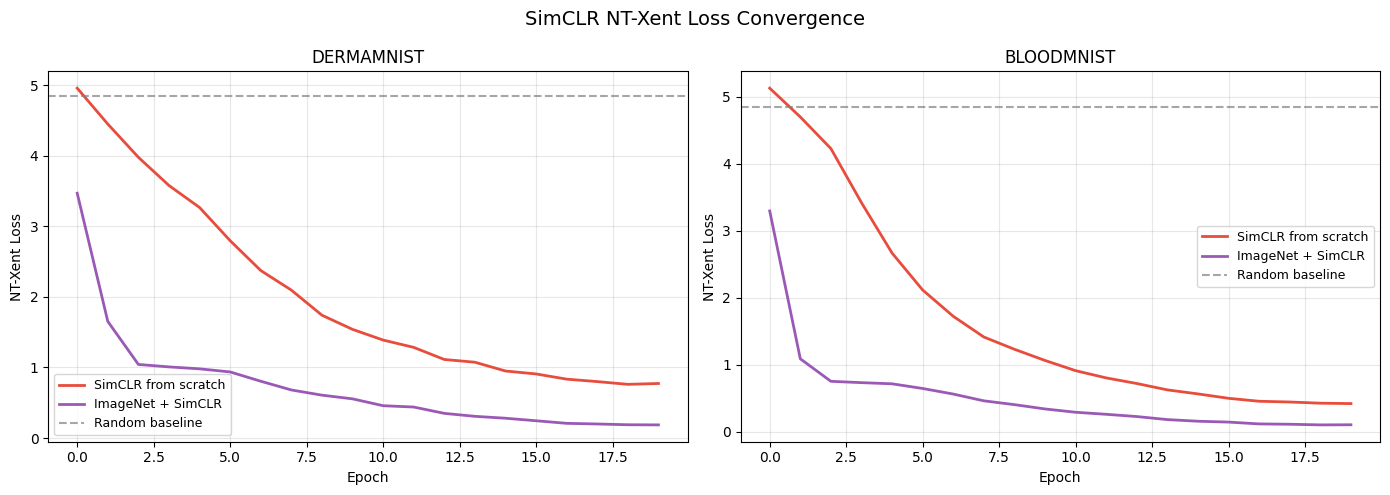

In [ ]:
# SSL convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SimCLR NT-Xent Loss Convergence', fontsize=14)
for ax, ds_name in zip(axes, DATASETS):
    for variant, color, label in [
        ('ssl_only',     '#e74c3c', 'SimCLR from scratch'),
        ('imagenet_ssl', '#9b59b6', 'ImageNet + SimCLR'),
    ]:
        ax.plot(ssl_loss_histories[ds_name][variant], color=color, lw=2, label=label)
    N = SSL_CONFIG['batch_size']
    ax.axhline(np.log(2*N-1), color='gray', ls='--', alpha=0.7, label='Random baseline')
    ax.set_title(ds_name.upper()); ax.set_xlabel('Epoch'); ax.set_ylabel('NT-Xent Loss')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/S3_ssl_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


  t-SNE: SimCLR (before fine-tuning)... done
  t-SNE: SimCLR → Fine-Tune... done
  t-SNE: ImageNet+SimCLR → Fine-Tune... done


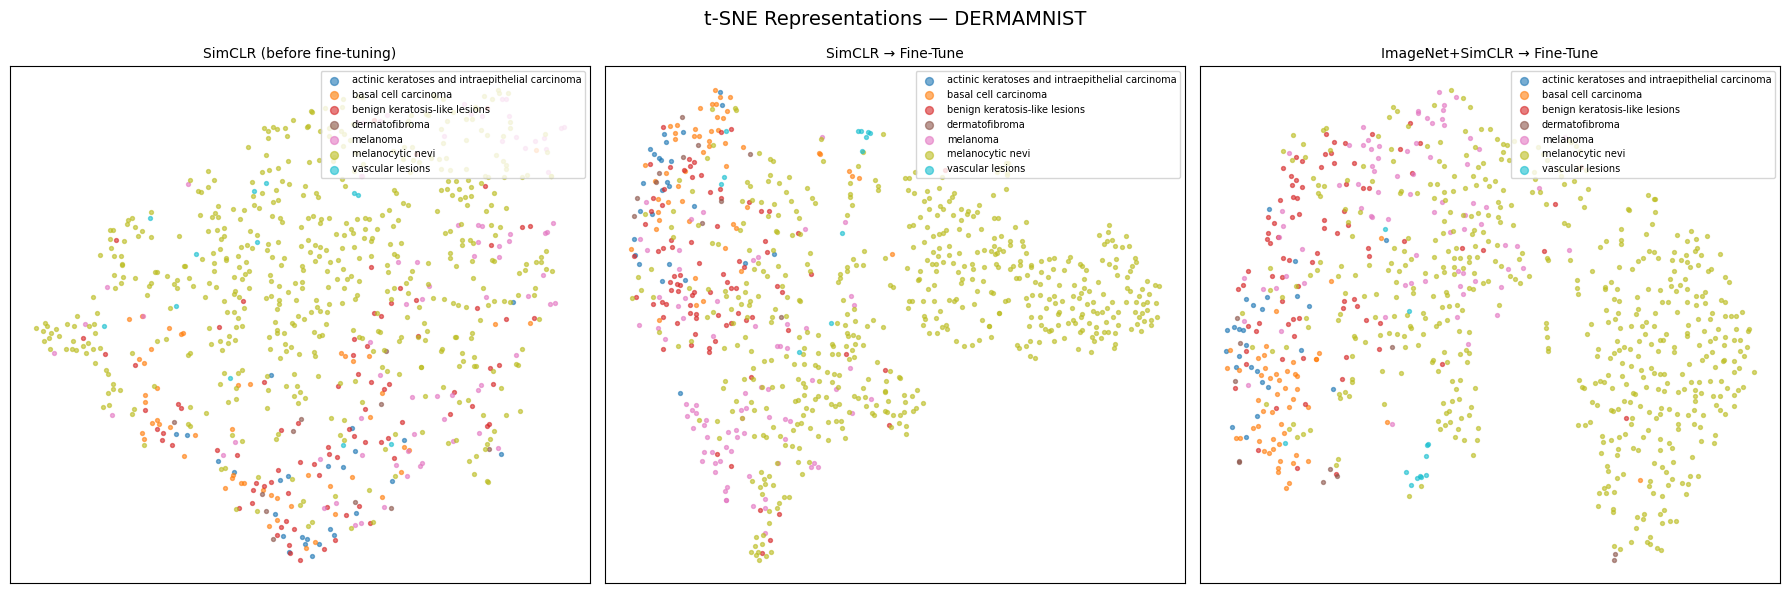

  t-SNE: SimCLR (before fine-tuning)... done
  t-SNE: SimCLR → Fine-Tune... done
  t-SNE: ImageNet+SimCLR → Fine-Tune... done


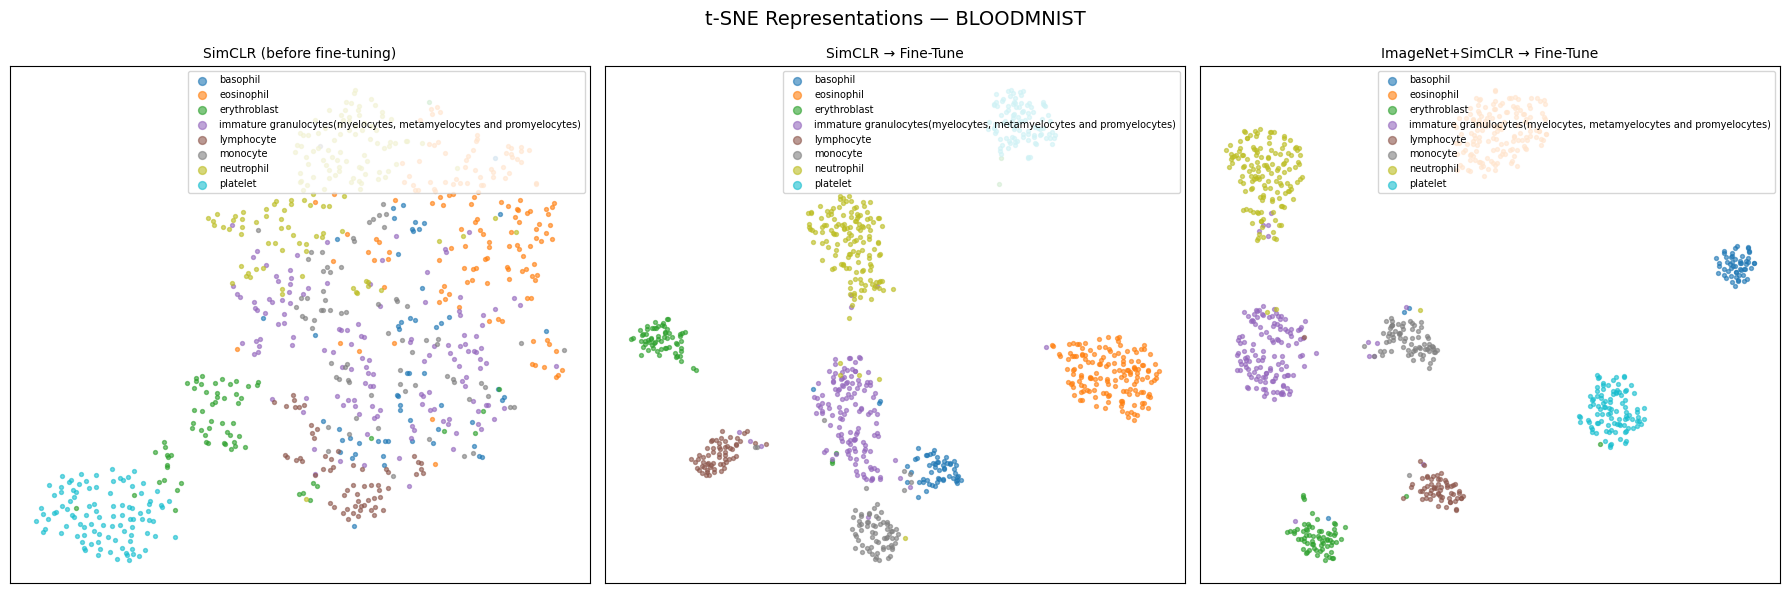

In [ ]:
@torch.no_grad()
def extract_features(model, loader, is_simclr=False, max_samples=800):
    model.eval()
    all_feats, all_labels = [], []
    total = 0
    for images, labels in loader:
        if total >= max_samples:
            break
        images = images.to(DEVICE)
        labels = labels.squeeze().long()
        if is_simclr:
            feats = model.encode(images)
        else:
            feats = model.encoder(images).flatten(start_dim=1)
        all_feats.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())
        total += images.size(0)
    return np.concatenate(all_feats)[:max_samples], np.concatenate(all_labels)[:max_samples]


for ds_name in DATASETS:
    info = INFO[ds_name]
    class_names = list(info['label'].values())
    n_cls = len(class_names)
    test_loader = ssl_loaders[ds_name]['ft_test']

    comparisons = [
        ('SimCLR (before fine-tuning)',   ssl_pretrained[ds_name]['ssl_only'],                              True),
        ('SimCLR → Fine-Tune',            ssl_ft_models[ds_name]['ssl_only_full_finetune'],                 False),
        ('ImageNet+SimCLR → Fine-Tune',   ssl_ft_models[ds_name]['imagenet_ssl_full_finetune'],             False),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f't-SNE Representations — {ds_name.upper()}', fontsize=14)
    cmap = plt.cm.tab10(np.linspace(0, 1, n_cls))

    for ax, (title, model, is_simclr) in zip(axes, comparisons):
        feats, labels = extract_features(model, test_loader, is_simclr=is_simclr)
        print(f"  t-SNE: {title}...", end=' ')
        emb = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000).fit_transform(feats)
        print("done")
        for cls_idx in range(n_cls):
            mask = labels == cls_idx
            ax.scatter(emb[mask,0], emb[mask,1], c=[cmap[cls_idx]], s=8, alpha=0.6,
                       label=class_names[cls_idx])
        ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
        ax.legend(fontsize=7, loc='upper right', markerscale=2)

    plt.tight_layout()
    plt.savefig(f'figures/S3_tsne_{ds_name}.png', dpi=100, bbox_inches='tight')
    plt.show()


## Section 4 — Double Transfer Learning

Two-stage fine-tuning using an intermediate medical domain:

| Direction | Stage 1 | Stage 2 |
|-----------|---------|---------|
| **A** | ImageNet → BloodMNIST | → DermaMNIST |
| **B** | ImageNet → DermaMNIST | → BloodMNIST |

Compared against single-transfer baselines (ImageNet → target directly).


In [8]:
def build_resnet50_double(num_classes, pretrained_weights=None):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    if pretrained_weights is not None:
        w = {k: v for k, v in pretrained_weights.items()
             if not k.startswith('fc.')}
        missing, unexpected = model.load_state_dict(w, strict=False)
        if missing:
            print(f"  Missing keys (expected - FC): {missing}")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)


def run_double_training(model, train_loader, val_loader, epochs, lr,
                         label='exp', patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss, best_state, patience_counter = float('inf'), None, 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        for k, v in zip(['train_loss','train_acc','val_loss','val_acc'],
                        [tr_loss, tr_acc, vl_loss, vl_acc]):
            history[k].append(v)
        print(f"[{label}] Ep {epoch:02d}/{epochs} | "
              f"Train {tr_loss:.4f}/{tr_acc:.3f} | Val {vl_loss:.4f}/{vl_acc:.3f} | "
              f"{time.time()-t0:.1f}s")
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss; patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stop at epoch {epoch}")
                break
    model.load_state_dict(best_state)
    return history, model.state_dict()


### 4.1 Direction A: ImageNet → BloodMNIST → DermaMNIST

In [9]:
set_seed()
WEIGHT_DECAY = CONFIG['weight_decay']
print("="*60 + "\nDIRECTION A: Blood (Stage 1) → Derma (Stage 2)\n" + "="*60)

# Stage 1
print("\n[Stage 1] ImageNet → BloodMNIST")
model_A1 = build_resnet50_double(num_classes=dataloaders['bloodmnist']['n_classes'])
history_A1, weights_A1 = run_double_training(
    model_A1, dataloaders['bloodmnist']['train'], dataloaders['bloodmnist']['val'],
    epochs=EPOCHS_STAGE1, lr=LR_STAGE1, label="DirA-S1-Blood")
torch.save(weights_A1, "checkpoints/dirA_stage1_blood.pth")

# Stage 2
print("\n[Stage 2] BloodMNIST weights → DermaMNIST")
model_A2 = build_resnet50_double(num_classes=dataloaders['dermamnist']['n_classes'],
                                  pretrained_weights=weights_A1)
history_A2, weights_A2 = run_double_training(
    model_A2, dataloaders['dermamnist']['train'], dataloaders['dermamnist']['val'],
    epochs=EPOCHS_STAGE2, lr=LR_STAGE2, label="DirA-S2-Derma")
torch.save(weights_A2, "checkpoints/dirA_stage2_derma.pth")

_, test_acc_A, preds_A, labels_A, _ = evaluate(model_A2, dataloaders['dermamnist']['test'])
print(f"\n[Direction A] DermaMNIST Test Accuracy: {test_acc_A:.4f}")
print(classification_report(labels_A, preds_A,
                              target_names=list(INFO['dermamnist']['label'].values()), digits=4))


DIRECTION A: Blood (Stage 1) → Derma (Stage 2)

[Stage 1] ImageNet → BloodMNIST


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 246MB/s]


[DirA-S1-Blood] Ep 01/15 | Train 0.3827/0.871 | Val 0.1513/0.956 | 125.2s
[DirA-S1-Blood] Ep 02/15 | Train 0.1679/0.939 | Val 0.1577/0.945 | 126.2s
[DirA-S1-Blood] Ep 03/15 | Train 0.1378/0.953 | Val 0.1057/0.959 | 126.4s
[DirA-S1-Blood] Ep 04/15 | Train 0.1158/0.961 | Val 0.0948/0.966 | 126.5s
[DirA-S1-Blood] Ep 05/15 | Train 0.0855/0.970 | Val 0.0968/0.964 | 126.6s
[DirA-S1-Blood] Ep 06/15 | Train 0.0789/0.973 | Val 0.0982/0.964 | 126.4s
[DirA-S1-Blood] Ep 07/15 | Train 0.0606/0.979 | Val 0.0790/0.973 | 126.4s
[DirA-S1-Blood] Ep 08/15 | Train 0.0523/0.983 | Val 0.0845/0.970 | 126.4s
[DirA-S1-Blood] Ep 09/15 | Train 0.0379/0.988 | Val 0.0985/0.968 | 126.4s
[DirA-S1-Blood] Ep 10/15 | Train 0.0301/0.991 | Val 0.0765/0.975 | 126.4s
[DirA-S1-Blood] Ep 11/15 | Train 0.0242/0.992 | Val 0.0760/0.976 | 126.4s
[DirA-S1-Blood] Ep 12/15 | Train 0.0215/0.994 | Val 0.0613/0.979 | 126.4s
[DirA-S1-Blood] Ep 13/15 | Train 0.0141/0.996 | Val 0.0618/0.979 | 126.4s
[DirA-S1-Blood] Ep 14/15 | Train 0.014

### 4.2 Direction B: ImageNet → DermaMNIST → BloodMNIST

In [10]:
set_seed()
print("="*60 + "\nDIRECTION B: Derma (Stage 1) → Blood (Stage 2)\n" + "="*60)

# Stage 1
print("\n[Stage 1] ImageNet → DermaMNIST")
model_B1 = build_resnet50_double(num_classes=dataloaders['dermamnist']['n_classes'])
history_B1, weights_B1 = run_double_training(
    model_B1, dataloaders['dermamnist']['train'], dataloaders['dermamnist']['val'],
    epochs=EPOCHS_STAGE1, lr=LR_STAGE1, label="DirB-S1-Derma")
torch.save(weights_B1, "checkpoints/dirB_stage1_derma.pth")

# Stage 2
print("\n[Stage 2] DermaMNIST weights → BloodMNIST")
model_B2 = build_resnet50_double(num_classes=dataloaders['bloodmnist']['n_classes'],
                                  pretrained_weights=weights_B1)
history_B2, weights_B2 = run_double_training(
    model_B2, dataloaders['bloodmnist']['train'], dataloaders['bloodmnist']['val'],
    epochs=EPOCHS_STAGE2, lr=LR_STAGE2, label="DirB-S2-Blood")
torch.save(weights_B2, "checkpoints/dirB_stage2_blood.pth")

_, test_acc_B, preds_B, labels_B, _ = evaluate(model_B2, dataloaders['bloodmnist']['test'])
print(f"\n[Direction B] BloodMNIST Test Accuracy: {test_acc_B:.4f}")
print(classification_report(labels_B, preds_B,
                              target_names=list(INFO['bloodmnist']['label'].values()), digits=4))


DIRECTION B: Derma (Stage 1) → Blood (Stage 2)

[Stage 1] ImageNet → DermaMNIST
[DirB-S1-Derma] Ep 01/15 | Train 0.8424/0.703 | Val 0.6903/0.746 | 74.3s
[DirB-S1-Derma] Ep 02/15 | Train 0.6760/0.751 | Val 0.6486/0.766 | 74.4s
[DirB-S1-Derma] Ep 03/15 | Train 0.6247/0.767 | Val 0.6569/0.761 | 74.3s
[DirB-S1-Derma] Ep 04/15 | Train 0.5840/0.787 | Val 0.6284/0.778 | 74.5s
[DirB-S1-Derma] Ep 05/15 | Train 0.5460/0.790 | Val 0.6006/0.786 | 74.3s
[DirB-S1-Derma] Ep 06/15 | Train 0.5047/0.810 | Val 0.6150/0.783 | 74.3s
[DirB-S1-Derma] Ep 07/15 | Train 0.4535/0.829 | Val 0.6092/0.773 | 74.3s
[DirB-S1-Derma] Ep 08/15 | Train 0.4000/0.849 | Val 0.6303/0.777 | 74.3s
[DirB-S1-Derma] Ep 09/15 | Train 0.3314/0.881 | Val 0.6483/0.765 | 74.3s
[DirB-S1-Derma] Ep 10/15 | Train 0.2773/0.900 | Val 0.6758/0.782 | 74.3s
  Early stop at epoch 10

[Stage 2] DermaMNIST weights → BloodMNIST
  Missing keys (expected - FC): ['fc.weight', 'fc.bias']
[DirB-S2-Blood] Ep 01/15 | Train 0.9018/0.744 | Val 0.3114/0.908 

### 4.3 Single-Transfer Baselines

In [11]:
set_seed()
print("Running single-transfer baselines...")

model_base_derma = build_resnet50_double(num_classes=dataloaders['dermamnist']['n_classes'])
history_base_derma, _ = run_double_training(
    model_base_derma, dataloaders['dermamnist']['train'], dataloaders['dermamnist']['val'],
    epochs=EPOCHS_STAGE1, lr=LR_STAGE1, label="Baseline-Derma")
_, acc_base_derma, preds_bd, labels_bd, _ = evaluate(model_base_derma, dataloaders['dermamnist']['test'])
print(f"\nBaseline DermaMNIST Test Accuracy: {acc_base_derma:.4f}")

set_seed()
model_base_blood = build_resnet50_double(num_classes=dataloaders['bloodmnist']['n_classes'])
history_base_blood, _ = run_double_training(
    model_base_blood, dataloaders['bloodmnist']['train'], dataloaders['bloodmnist']['val'],
    epochs=EPOCHS_STAGE1, lr=LR_STAGE1, label="Baseline-Blood")
_, acc_base_blood, preds_bb, labels_bb, _ = evaluate(model_base_blood, dataloaders['bloodmnist']['test'])
print(f"Baseline BloodMNIST Test Accuracy : {acc_base_blood:.4f}")


Running single-transfer baselines...
[Baseline-Derma] Ep 01/15 | Train 0.8424/0.703 | Val 0.6903/0.746 | 73.5s
[Baseline-Derma] Ep 02/15 | Train 0.6760/0.751 | Val 0.6486/0.766 | 74.1s
[Baseline-Derma] Ep 03/15 | Train 0.6247/0.767 | Val 0.6569/0.761 | 74.3s
[Baseline-Derma] Ep 04/15 | Train 0.5840/0.787 | Val 0.6284/0.778 | 74.3s
[Baseline-Derma] Ep 05/15 | Train 0.5460/0.790 | Val 0.6006/0.786 | 74.3s
[Baseline-Derma] Ep 06/15 | Train 0.5047/0.810 | Val 0.6150/0.783 | 74.3s
[Baseline-Derma] Ep 07/15 | Train 0.4535/0.829 | Val 0.6092/0.773 | 74.3s
[Baseline-Derma] Ep 08/15 | Train 0.4000/0.849 | Val 0.6303/0.777 | 74.3s
[Baseline-Derma] Ep 09/15 | Train 0.3314/0.881 | Val 0.6483/0.765 | 74.3s
[Baseline-Derma] Ep 10/15 | Train 0.2773/0.900 | Val 0.6758/0.782 | 74.3s
  Early stop at epoch 10

Baseline DermaMNIST Test Accuracy: 0.7761
[Baseline-Blood] Ep 01/15 | Train 0.3827/0.871 | Val 0.1513/0.956 | 126.4s
[Baseline-Blood] Ep 02/15 | Train 0.1679/0.939 | Val 0.1577/0.945 | 126.4s
[Base

### 4.4 Double Transfer: Learning Curves & Confusion Matrices

Saved: figures/S4_dirA_curves.png


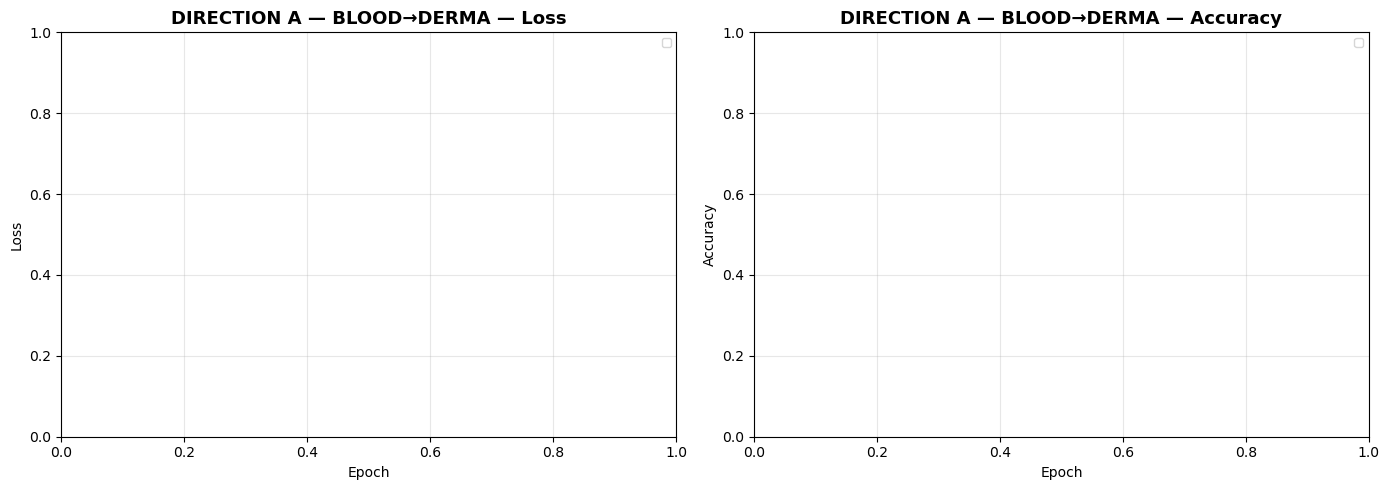

Saved: figures/S4_dirB_curves.png


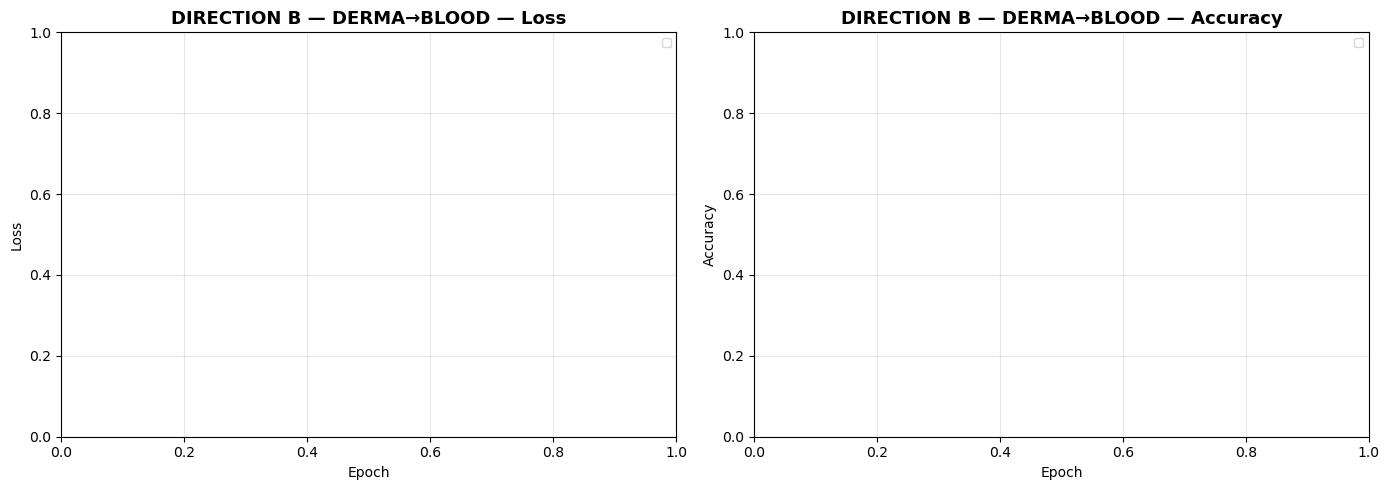

Saved: figures/S4_cm_dirA.png


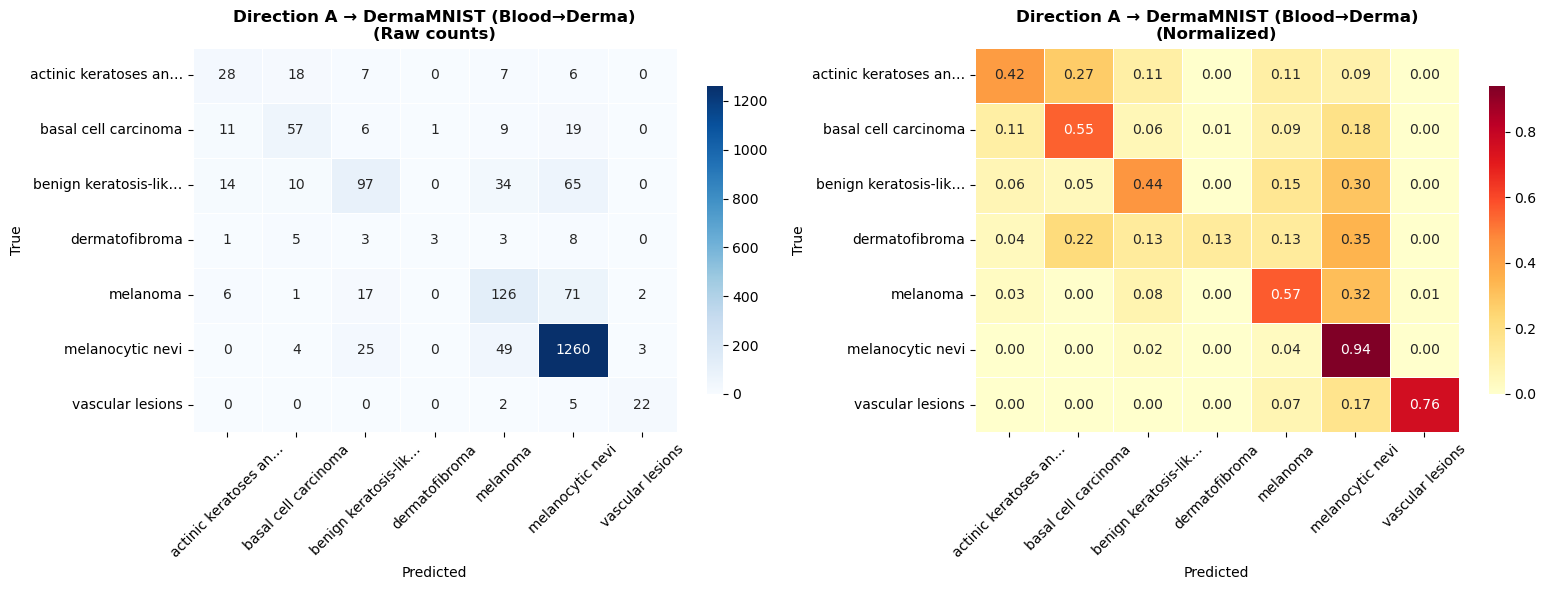

Saved: figures/S4_cm_dirB.png


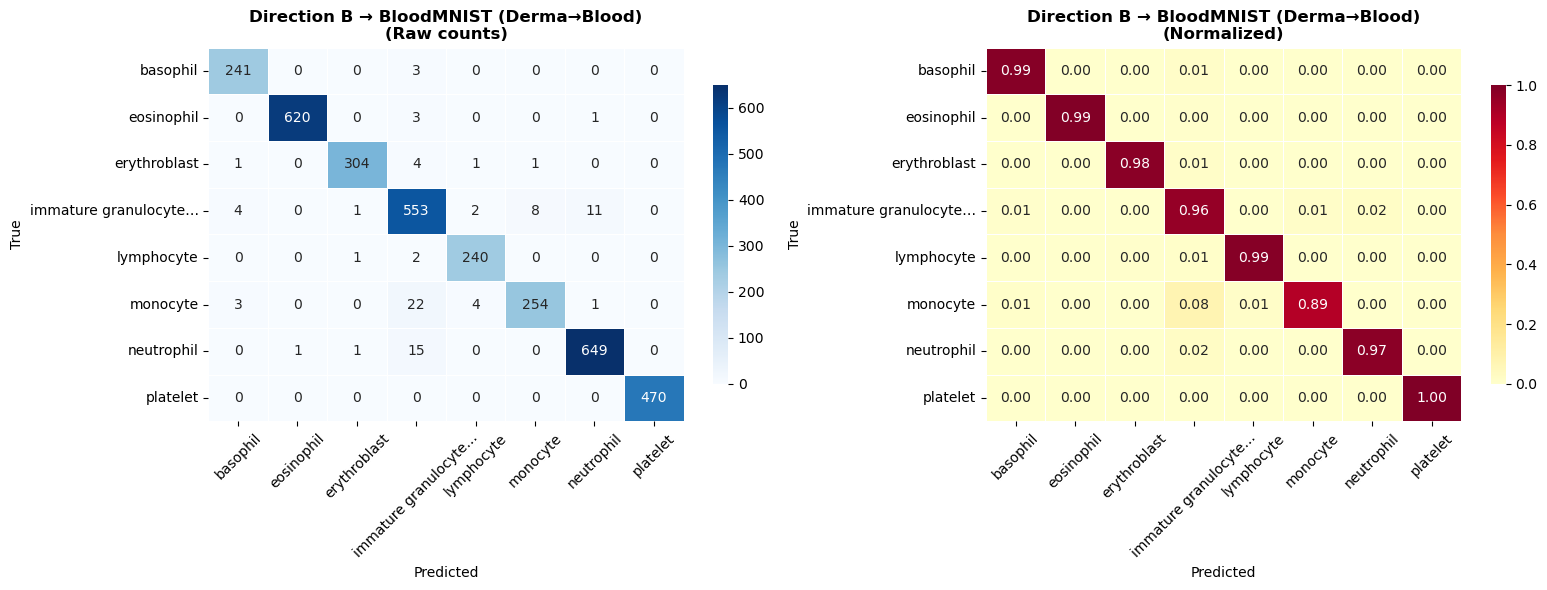

Saved: figures/S4_cm_base_derma.png


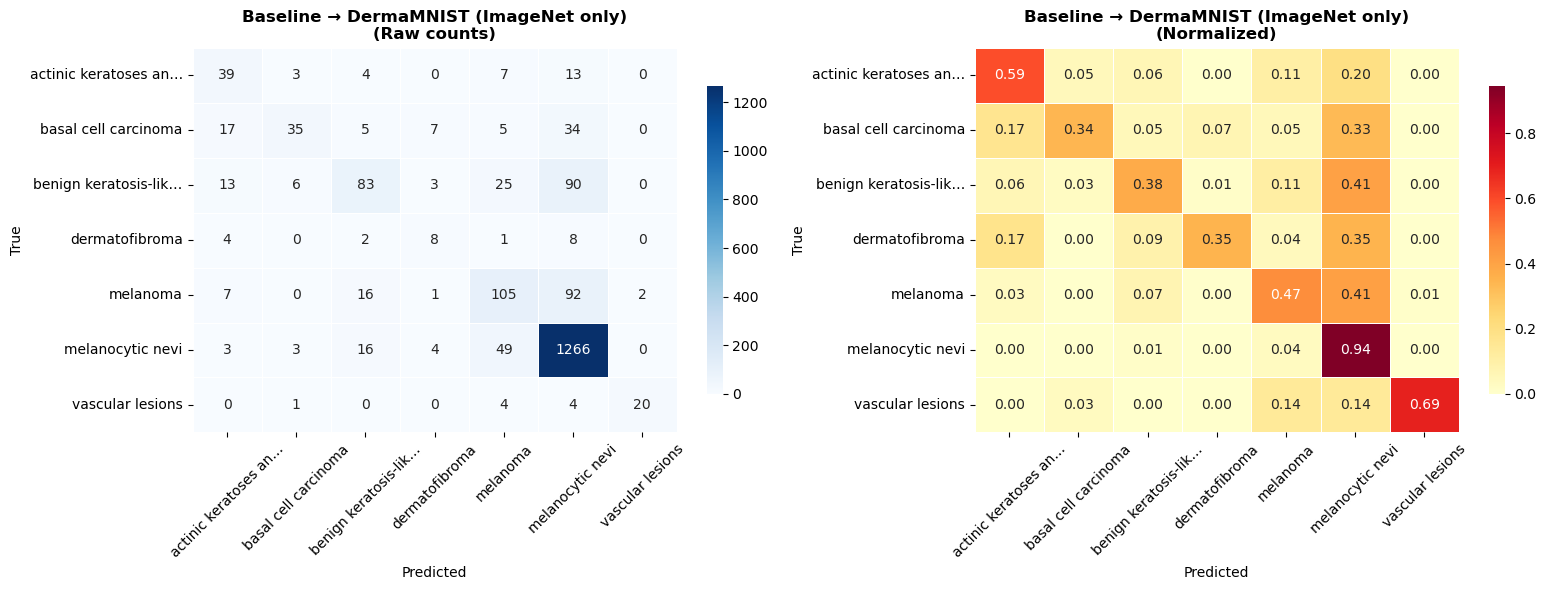

Saved: figures/S4_cm_base_blood.png


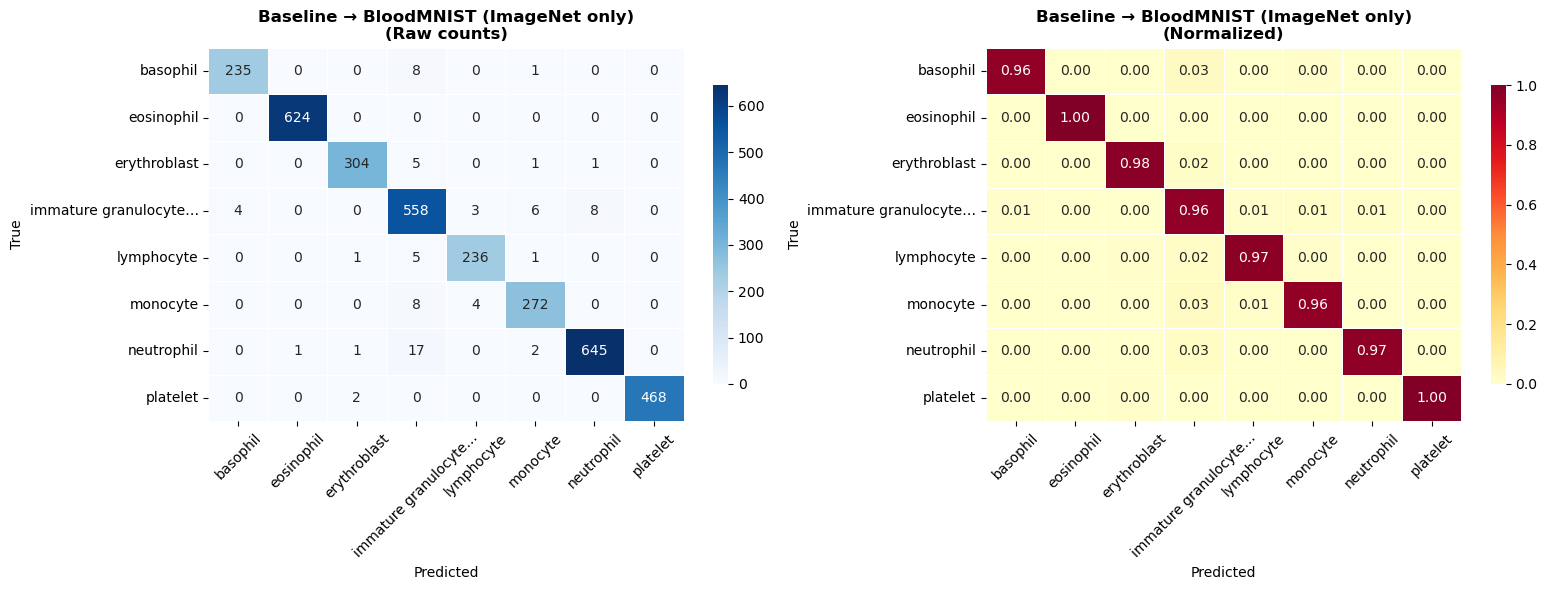


  DOUBLE TRANSFER SUMMARY
Method                                        Dataset         Acc
------------------------------------------------------------
Baseline (ImageNet → Derma)                   DermaMNIST   0.7761
Double Transfer A (ImageNet→Blood→Derma)      DermaMNIST   0.7945
Baseline (ImageNet → Blood)                   BloodMNIST   0.9769
Double Transfer B (ImageNet→Derma→Blood)      BloodMNIST   0.9737
Double Transfer gain on DermaMNIST: +0.0185
Double Transfer gain on BloodMNIST : -0.0032


In [12]:
derma_labels = list(INFO['dermamnist']['label'].values())
blood_labels = list(INFO['bloodmnist']['label'].values())

plot_learning_curves(
    {"Stage1-Blood": history_A1, "Stage2-Derma (double)": history_A2},
    'Direction A — Blood→Derma', ['Stage1-Blood', 'Stage2-Derma (double)'],
    save_path='figures/S4_dirA_curves.png'
)
plot_learning_curves(
    {"Stage1-Derma": history_B1, "Stage2-Blood (double)": history_B2},
    'Direction B — Derma→Blood', ['Stage1-Derma', 'Stage2-Blood (double)'],
    save_path='figures/S4_dirB_curves.png'
)

plot_confusion_matrix(preds_A, labels_A, derma_labels,
                      "Direction A → DermaMNIST (Blood→Derma)", 'figures/S4_cm_dirA.png')
plot_confusion_matrix(preds_B, labels_B, blood_labels,
                      "Direction B → BloodMNIST (Derma→Blood)", 'figures/S4_cm_dirB.png')
plot_confusion_matrix(preds_bd, labels_bd, derma_labels,
                      "Baseline → DermaMNIST (ImageNet only)", 'figures/S4_cm_base_derma.png')
plot_confusion_matrix(preds_bb, labels_bb, blood_labels,
                      "Baseline → BloodMNIST (ImageNet only)", 'figures/S4_cm_base_blood.png')

print("\n" + "="*60 + "\n  DOUBLE TRANSFER SUMMARY\n" + "="*60)
print(f"{'Method':<45} {'Dataset':<12} {'Acc':>6}")
print("-"*60)
print(f"{'Baseline (ImageNet → Derma)':<45} {'DermaMNIST':<12} {acc_base_derma:.4f}")
print(f"{'Double Transfer A (ImageNet→Blood→Derma)':<45} {'DermaMNIST':<12} {test_acc_A:.4f}")
print(f"{'Baseline (ImageNet → Blood)':<45} {'BloodMNIST':<12} {acc_base_blood:.4f}")
print(f"{'Double Transfer B (ImageNet→Derma→Blood)':<45} {'BloodMNIST':<12} {test_acc_B:.4f}")
print("="*60)
print(f"Double Transfer gain on DermaMNIST: {test_acc_A - acc_base_derma:+.4f}")
print(f"Double Transfer gain on BloodMNIST : {test_acc_B - acc_base_blood:+.4f}")


In [ ]:
# ── Build master results table ─────────────────────────────────────────────
rows = []

# Section 2: Fine-Tuning
for key, r in ft_results.items():
    rows.append({
        'Section'    : 'S2 Fine-Tuning',
        'Method'     : r['mode'].replace('_', ' ').title(),
        'Dataset'    : r['dataset'].upper(),
        'Test Acc'   : round(r['test_acc'],  4),
        'Macro AUC'  : round(r['auc'],       4),
        'Macro F1'   : round(r['f1_macro'],  4),
    })

# Section 3: SSL
NICE = {
    'ssl_only_linear_eval'          : 'SimCLR (scratch) → Linear Eval',
    'ssl_only_full_finetune'        : 'SimCLR (scratch) → Full FT',
    'imagenet_ssl_linear_eval'      : 'ImageNet+SimCLR → Linear Eval',
    'imagenet_ssl_full_finetune'    : 'ImageNet+SimCLR → Full FT',
}
for ds in DATASETS:
    for variant_key, m in ssl_ft_results.items():
        if not variant_key.startswith(ds):
            continue
        short_key = variant_key[len(ds)+2:]  # strip "<ds>__"
        rows.append({
            'Section'    : 'S3 SimCLR SSL',
            'Method'     : NICE.get(short_key, short_key),
            'Dataset'    : ds.upper(),
            'Test Acc'   : round(m['accuracy'], 4),
            'Macro AUC'  : round(m['auc'],      4),
            'Macro F1'   : round(m['f1'],        4),
        })

# Section 4: Double Transfer
for method, ds, acc in [
    ('Baseline (ImageNet→Derma)',         'DERMAMNIST', acc_base_derma),
    ('Double TL A (ImageNet→Blood→Derma)','DERMAMNIST', test_acc_A),
    ('Baseline (ImageNet→Blood)',         'BLOODMNIST', acc_base_blood),
    ('Double TL B (ImageNet→Derma→Blood)','BLOODMNIST', test_acc_B),
]:
    rows.append({
        'Section'   : 'S4 Double TL',
        'Method'    : method,
        'Dataset'   : ds,
        'Test Acc'  : round(acc, 4),
        'Macro AUC' : None,
        'Macro F1'  : None,
    })

df_master = pd.DataFrame(rows)
df_master.to_csv('experiments/W3_unified_results.csv', index=False)

print("\n" + "="*80)
print("  UNIFIED RESULTS — Week 3")
print("="*80)
print(df_master.to_string(index=False))
print("\nSaved: experiments/W3_unified_results.csv")


### 5.1 Best Method per Dataset — Visual Comparison

In [ ]:
# Bar charts comparing best method per section per dataset
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Week 3 — Best Methods per Dataset (Test Accuracy)', fontsize=14)

for ax, ds in zip(axes, [d.upper() for d in DATASETS]):
    subset = df_master[df_master['Dataset'] == ds].dropna(subset=['Test Acc'])
    # Pick best per section
    best = subset.loc[subset.groupby('Section')['Test Acc'].idxmax()]
    colors = ['#4FC3F7', '#EF9A9A', '#A5D6A7']
    bars = ax.bar(best['Section'], best['Test Acc'],
                  color=colors[:len(best)], edgecolor='black', width=0.5)
    for bar, row in zip(bars, best.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{row._5:.4f}\n({row.Method[:20]})",
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(ds, fontsize=13, fontweight='bold')
    ax.set_ylabel('Test Accuracy')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('figures/S5_unified_best_per_section.png', dpi=150, bbox_inches='tight')
plt.show()
print("All results saved to experiments/ and figures/")
